In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("data/processed/loans_stage1.csv", low_memory=False)
print(df.shape)
df.head(3)

(1345350, 94)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,target
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,0


target
0    1076751
1     268599
Name: count, dtype: int64

Default rate: 19.96%


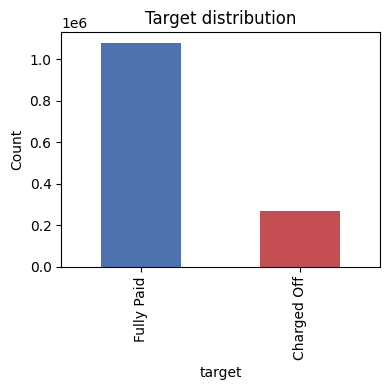

In [2]:
target_counts = df['target'].value_counts()
default_rate = df['target'].mean()

print(target_counts)
print(f"\nDefault rate: {default_rate:.2%}")

fig, ax = plt.subplots(figsize=(4, 4))
target_counts.rename({0: 'Fully Paid', 1: 'Charged Off'}).plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Target distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

77 numeric columns


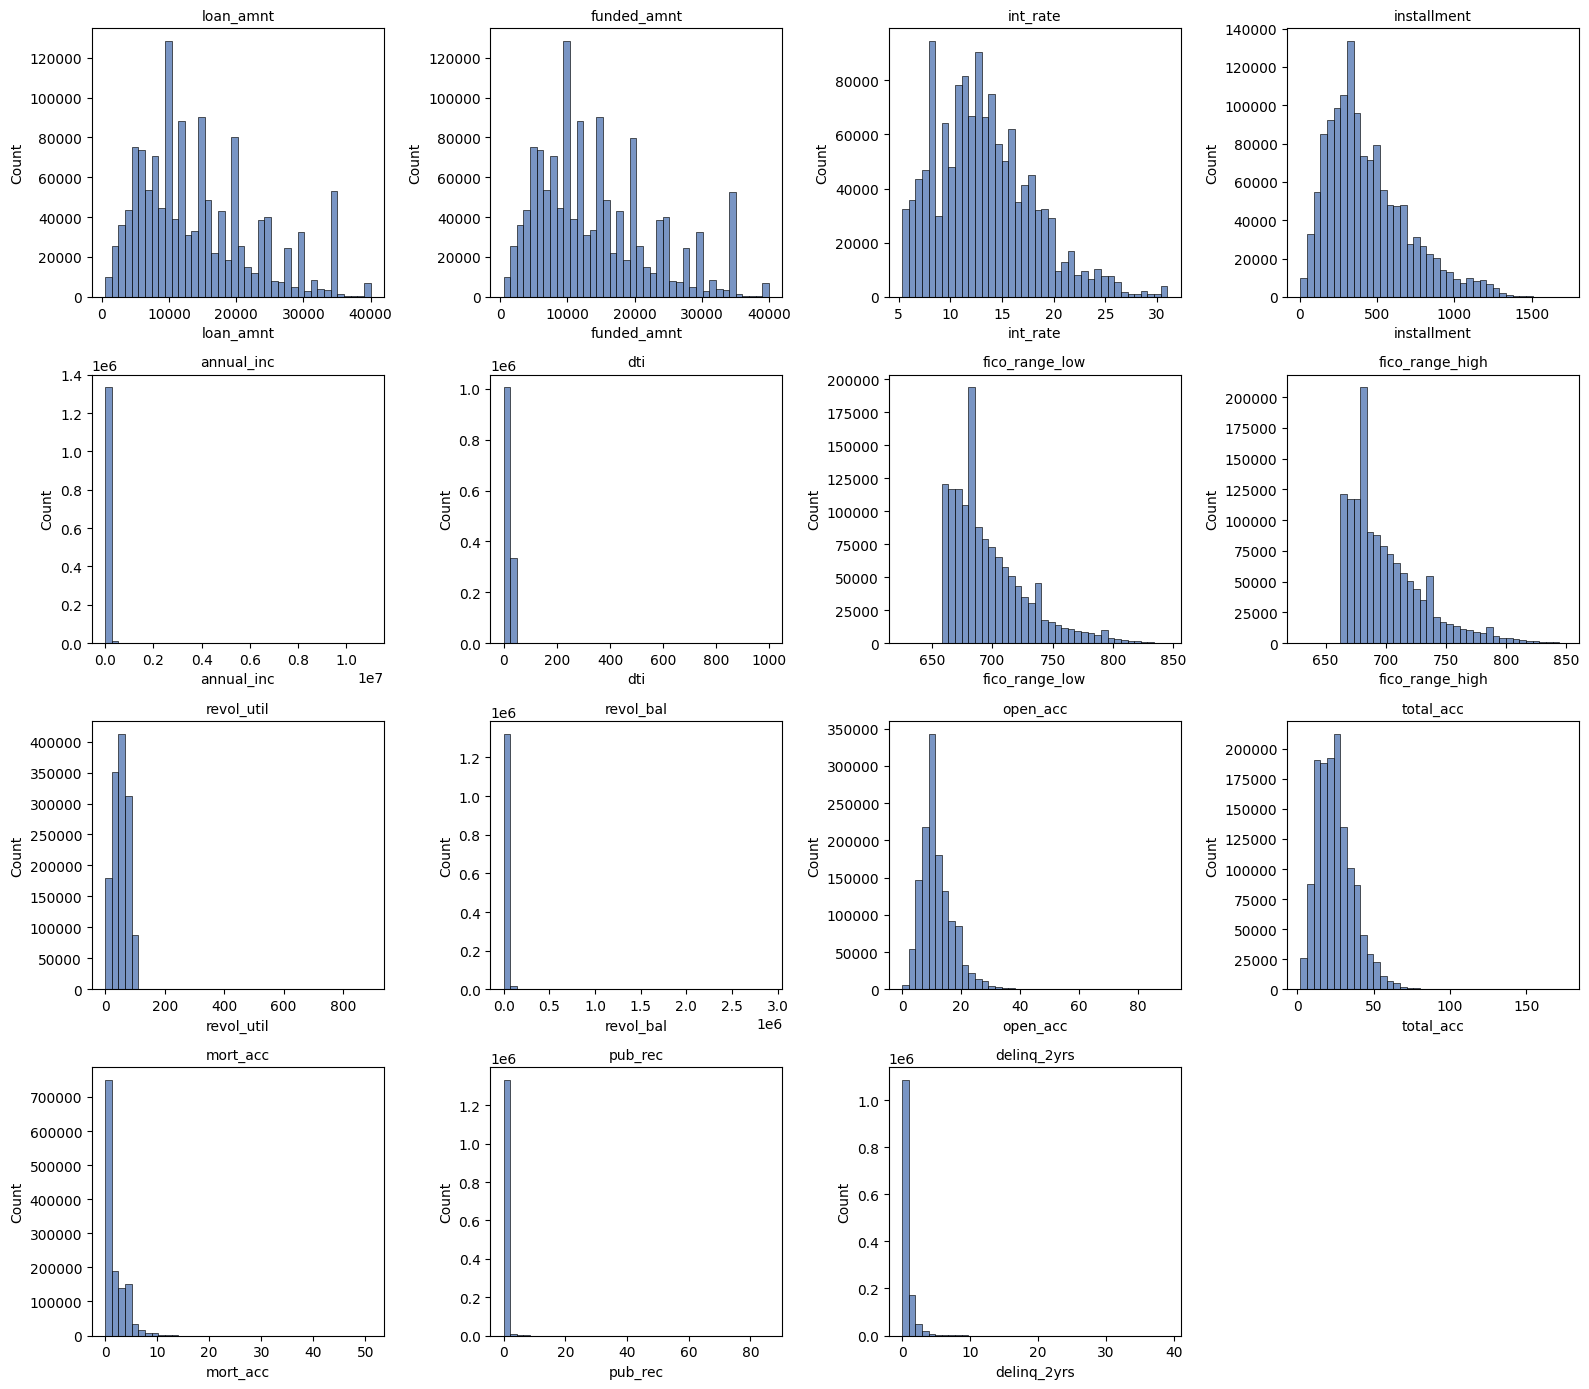

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']
print(f"{len(numeric_cols)} numeric columns")

core_numeric = [c for c in [
    'loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'fico_range_low', 'fico_range_high', 'revol_util', 'revol_bal',
    'open_acc', 'total_acc', 'mort_acc', 'pub_rec', 'delinq_2yrs',
] if c in df.columns]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.flat, core_numeric):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(core_numeric):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\konta\AppData\Local\Temp\ipykernel_2052\4275952653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\konta\AppData\Local\Temp\ipykernel_2052\4275952653.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fully Paid', 'Charged Off'])
C:\Users\konta\AppData\Local\Temp\ipykernel_2052\4275952653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\konta\AppData\Local\Temp\ipykernel_2052\4275952653.py:4: UserWarning: set_ticklabels(

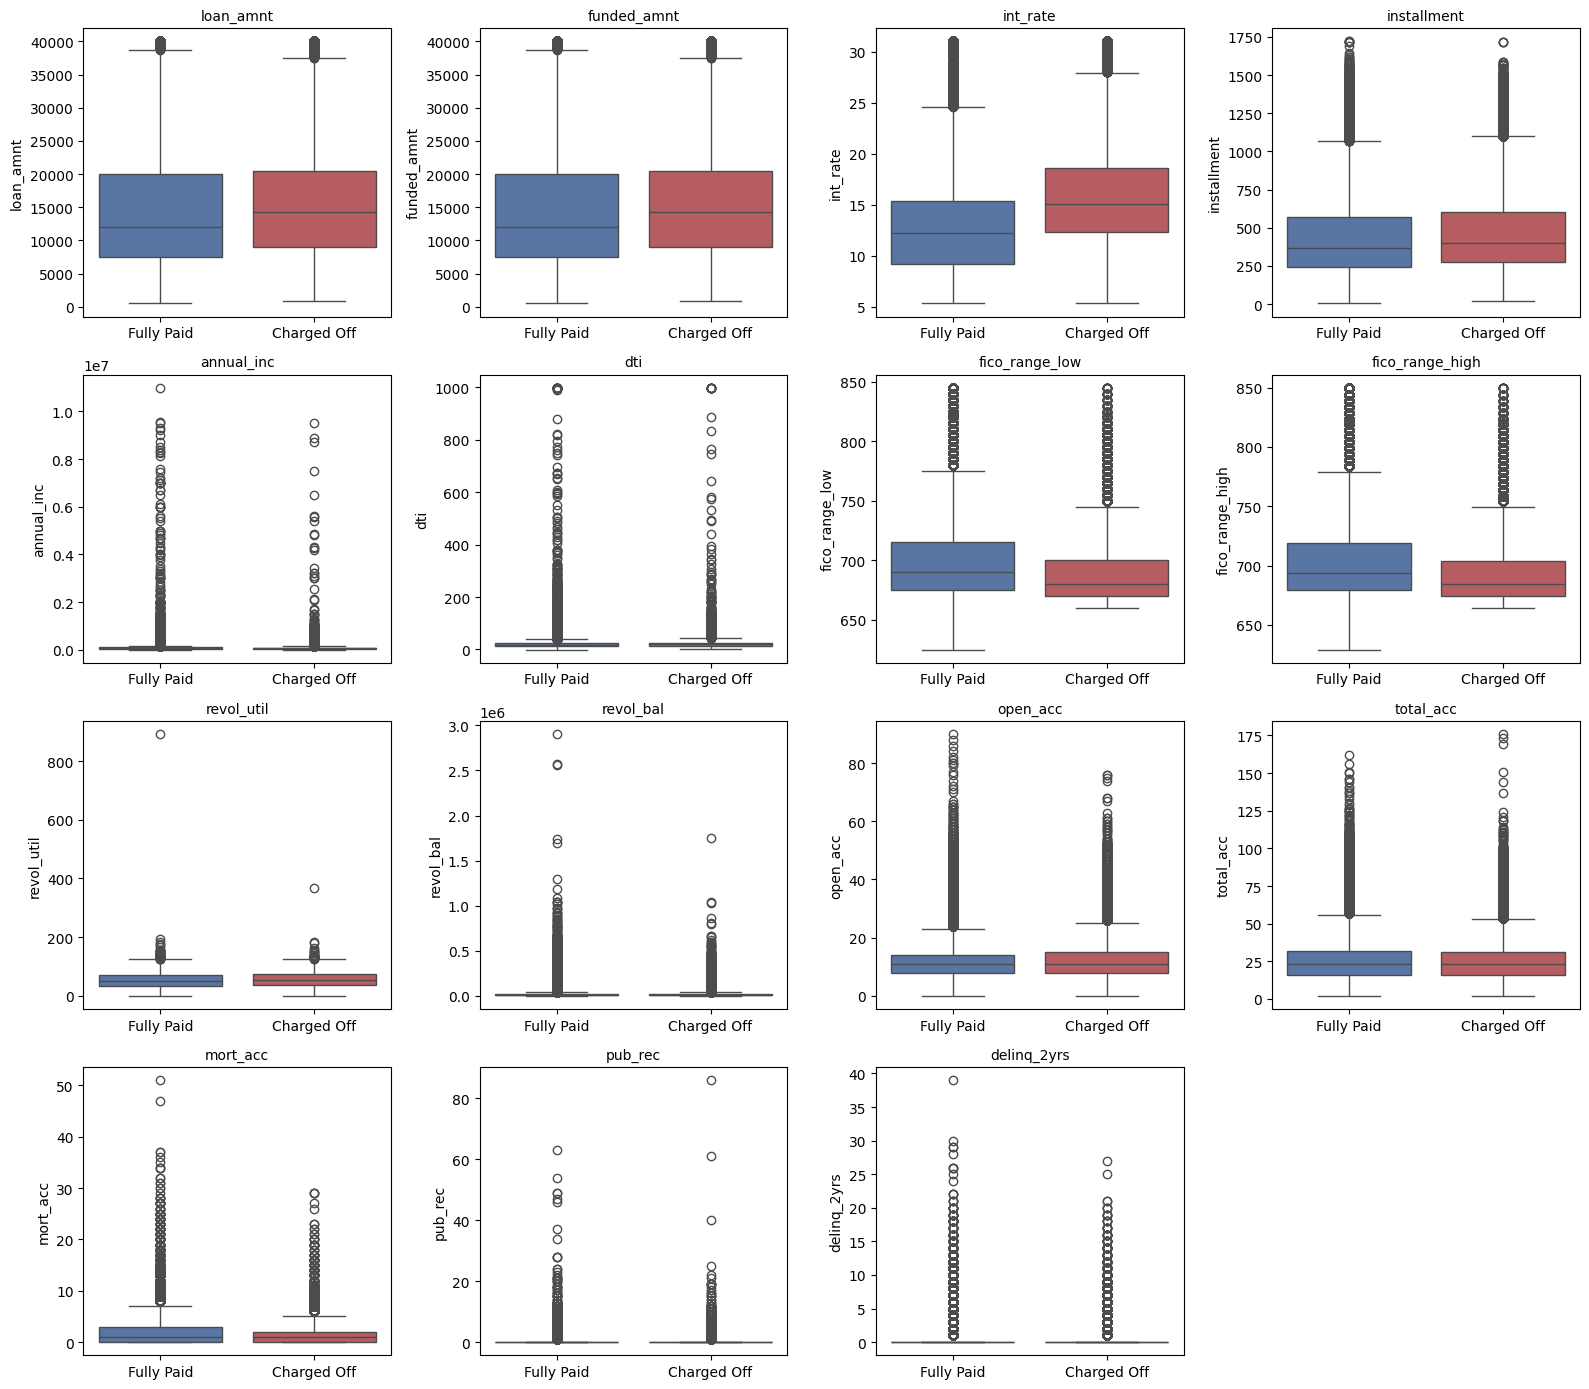

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.flat, core_numeric):
    sns.boxplot(data=df, x='target', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['Fully Paid', 'Charged Off'])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for ax in axes.flat[len(core_numeric):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
corrs = df[core_numeric + ['target']].corr(numeric_only=True)['target'].drop('target').sort_values(key=abs, ascending=False)
corrs.to_frame('corr_with_target')

,corr_with_target
int_rate,0.258806
fico_range_low,-0.130659
fico_range_high,-0.130658
dti,0.084499
mort_acc,-0.075303
funded_amnt,0.065652
loan_amnt,0.065598
revol_util,0.060024
installment,0.051697
annual_inc,-0.041758


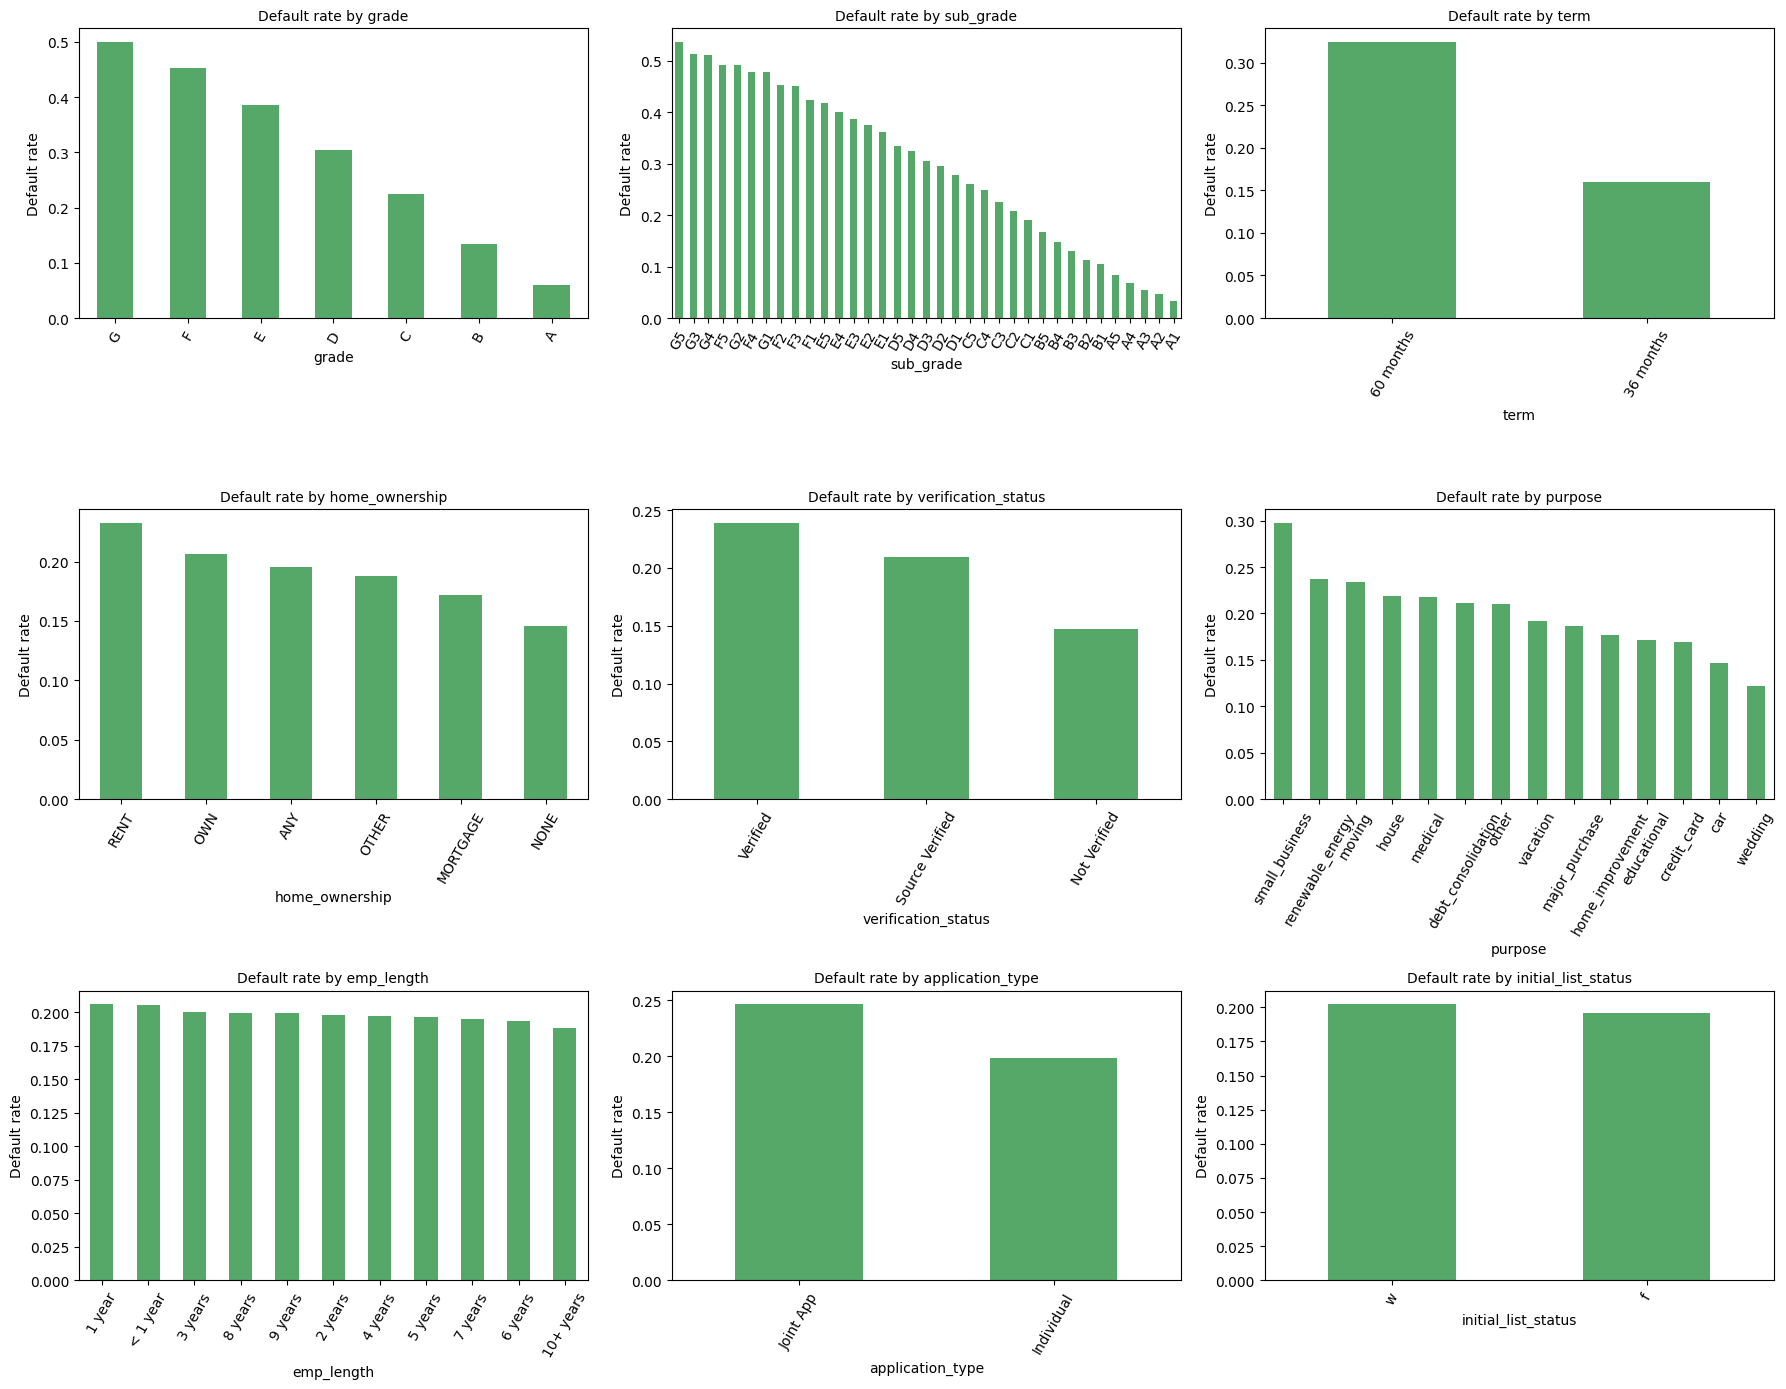

In [6]:
categorical_cols = [c for c in [
    'grade', 'sub_grade', 'term', 'home_ownership', 'verification_status',
    'purpose', 'emp_length', 'application_type', 'initial_list_status',
] if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flat, categorical_cols):
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'Default rate by {col}', fontsize=10)
    ax.set_ylabel('Default rate')
    ax.tick_params(axis='x', rotation=60)
for ax in axes.flat[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

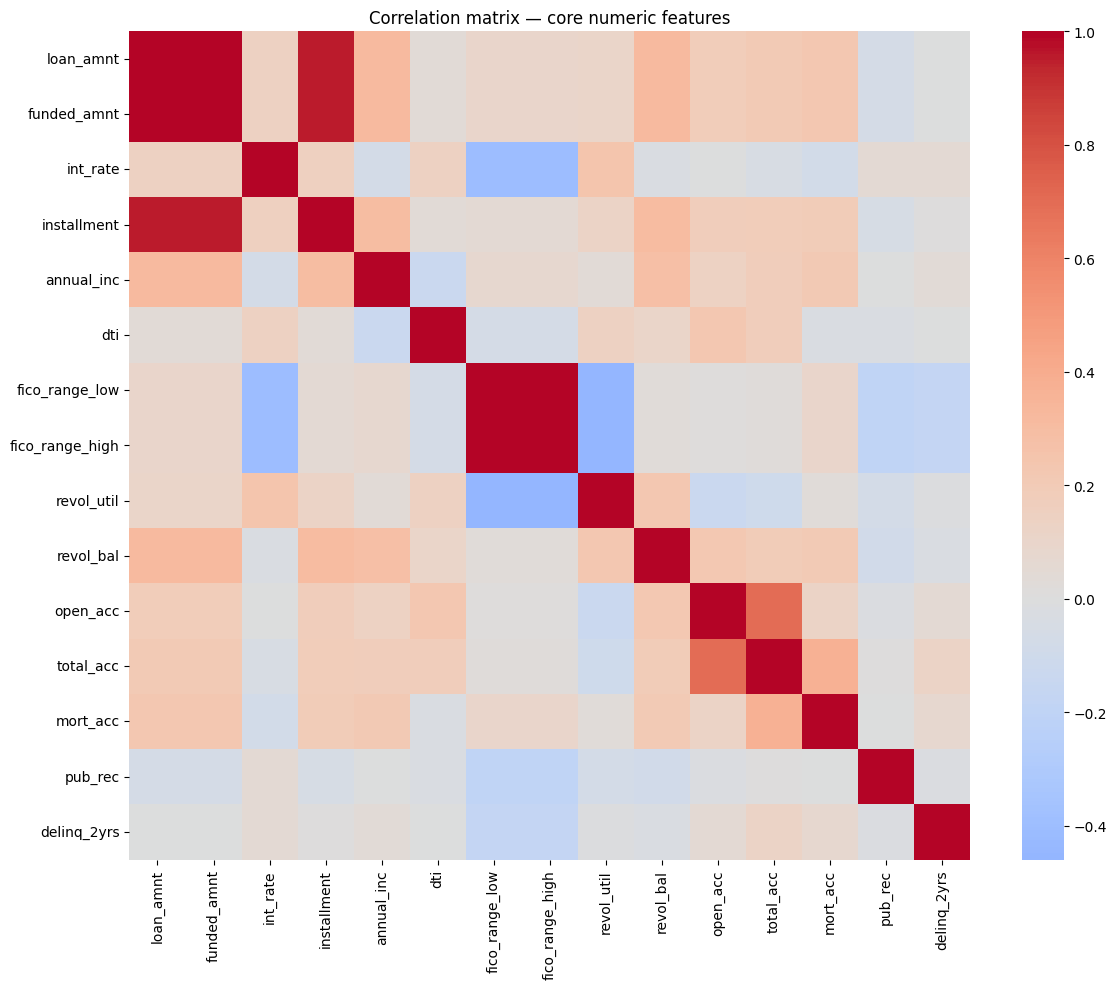

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[core_numeric].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix — core numeric features')
plt.tight_layout()
plt.show()

In [8]:
quality_notes = []

if 'annual_inc' in df.columns:
    q99 = df['annual_inc'].quantile(0.99)
    n_extreme = (df['annual_inc'] > q99 * 3).sum()
    quality_notes.append(f"annual_inc: {n_extreme} rows beyond 3x the 99th percentile ({q99:,.0f}) — consider capping/winsorizing")

if 'dti' in df.columns:
    n_negative = (df['dti'] < 0).sum()
    n_extreme = (df['dti'] > 100).sum()
    quality_notes.append(f"dti: {n_negative} negative values, {n_extreme} values > 100 — likely data errors, consider clipping")

if 'revol_util' in df.columns:
    n_over100 = (df['revol_util'] > 100).sum()
    quality_notes.append(f"revol_util: {n_over100} rows over 100% utilization — valid but rare, worth capping for modeling stability")

for note in quality_notes:
    print("-", note)

- annual_inc: 645 rows beyond 3x the 99th percentile (250,000) — consider capping/winsorizing
- dti: 2 negative values, 533 values > 100 — likely data errors, consider clipping
- revol_util: 4687 rows over 100% utilization — valid but rare, worth capping for modeling stability
